In [1]:
import ee
ee.Authenticate()

C:\Users\gudim\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [9]:
from datetime import datetime
import pandas as pd
def ee_millis_to_date(millis):
    return datetime.utcfromtimestamp(millis / 1000).strftime("%Y-%m-%d")

In [19]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

for f in valid_images:
    with rasterio.open(f) as src:
        ndvi   = src.read(1)
        evi    = src.read(2)
        rendvi = src.read(3)
        ndvi   = np.where(ndvi == src.nodata, np.nan, ndvi)
        evi    = np.where(evi == src.nodata, np.nan, evi)
        rendvi = np.where(rendvi == src.nodata, np.nan, rendvi)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(ndvi, cmap="YlGn")
    axes[0].set_title("NDVI (Band 1)")
    axes[0].axis("off")
    axes[1].imshow(evi, cmap="YlGn")
    axes[1].set_title("EVI (Band 2)")
    axes[1].axis("off")
    axes[2].imshow(rendvi, cmap="YlGn")
    axes[2].set_title("Red-Edge NDVI (Band 3)")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

In [1]:
from platform import python_version
print(python_version())

3.10.0


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# ---------------------------------
# Load features
# ---------------------------------
feat_df = pd.read_csv("ndvi_features.csv")

# ---------------------------------
# Feature space (MULTI-INDEX)
# ---------------------------------
feature_cols = [
    "mean_ndvi",
    "mean_evi",
    "mean_rendvi",
    "var_ndvi",
    "growth_rate_per_day"
]

X = feat_df[feature_cols].values

# Normalize
X_scaled = StandardScaler().fit_transform(X)

# ---------------------------------
# Select reference grid SAFELY
# ---------------------------------
ref_grid_id = int(
    input(f"Enter a grid_id to find similar grids (0–{feat_df['grid_id'].max()}): ")
)

# Find row index corresponding to grid_id
if ref_grid_id not in feat_df["grid_id"].values:
    raise ValueError("Invalid grid_id selected")

ref_idx = feat_df.index[feat_df["grid_id"] == ref_grid_id][0]

# ---------------------------------
# Distance calculation
# ---------------------------------
distances = euclidean_distances(
    X_scaled[ref_idx].reshape(1, -1),
    X_scaled
)[0]

feat_df["similarity_distance"] = distances

# ---------------------------------
# Pick top-K similar grids
# ---------------------------------
K = 20

similar_grids = (
    feat_df.sort_values("similarity_distance")
    .iloc[1:K+1]["grid_id"]
    .tolist()
)

print("Reference grid:", ref_grid_id)
print("Top similar grids:", similar_grids)

# ---------------------------------
# Label grids for visualization
# ---------------------------------
grid["label"] = "other"

grid.loc[grid["grid_id"] == ref_grid_id, "label"] = "reference"
grid.loc[grid["grid_id"].isin(similar_grids), "label"] = "similar"


In [ ]:
import rasterio
import numpy as np
from rasterio.plot import show

overlay_tiff = valid_images[len(valid_images)//2]
print("Using overlay:", overlay_tiff)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

with rasterio.open(overlay_tiff) as src:
    ndvi = src.read(1)
    bounds = src.bounds

    # Mask invalid values
    ndvi = np.where(np.isnan(ndvi), np.nan, ndvi)

    show(
        ndvi,
        ax=ax,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        cmap='Greys',
        alpha=1  # 👈 IMPORTANT: subtle overlay
    )
    
# Background grids
grid[grid["label"] == "other"].plot(
    ax=ax,
    color="none",
    edgecolor="lightgrey",
    linewidth=1
)

# Reference grid
grid[grid["label"] == "reference"].plot(
    ax=ax,
    color="limegreen",
    edgecolor="black",
    linewidth=1,
    label="Selected farm"
)

ax.set_title("User-Selected Farm Similarity with NDVI Overlay", fontsize=14)
ax.axis("off")
ax.legend()
plt.show()

In [ ]:
import numpy as np

# Copy to avoid modifying original
feat_vis = feat_df.copy()

# ---------------------------------
# Identify reference row
# ---------------------------------
ref_idx = feat_vis["similarity_distance"].idxmin()

# ---------------------------------
# Compute bins EXCLUDING reference
# ---------------------------------
non_ref_distances = feat_vis.loc[
    feat_vis.index != ref_idx, "similarity_distance"
]

bins = np.percentile(
    non_ref_distances,
    [5, 15, 30]
)

# ---------------------------------
# Classification function
# ---------------------------------
def classify_similarity(i, d):
    if i == ref_idx:
        return "reference"
    elif d <= bins[0]:
        return "very_similar"
    elif d <= bins[1]:
        return "moderately_similar"
    elif d <= bins[2]:
        return "weakly_similar"
    else:
        return "other"

# ---------------------------------
# Apply classification
# ---------------------------------
feat_vis["sim_class"] = [
    classify_similarity(i, d)
    for i, d in zip(feat_vis.index, feat_vis["similarity_distance"])
]

# ---------------------------------
# Check distribution
# ---------------------------------
print(feat_vis["sim_class"].value_counts())


In [4]:
import ee
import os
import requests
from datetime import datetime

# ==========================================
# INITIALIZE EARTH ENGINE
# ==========================================
ee.Initialize()

# ==========================================
# AOI
# ==========================================
AOI = ee.Geometry.Polygon(
    [[
            [
              79.85118421964597,
              14.56512826180709
            ],
            [
              79.83421275502718,
              14.539062572044742
            ],
            [
              79.91514209483245,
              14.502130756931763
            ],
            [
              79.92944848223556,
              14.527114674597172
            ],
            [
              79.85118421964597,
              14.56512826180709
            ]
          ]]
)

# ==========================================
# OUTPUT FOLDER
# ==========================================
out_dir = "Sentinel2_7Bands_Median"
os.makedirs(out_dir, exist_ok=True)

# ==========================================
# DATE RANGE
# ==========================================
START_DATE = "2024-03-01"
END_DATE   = "2024-10-01"
WINDOW_DAYS = 30  # for median composites

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def ee_millis_to_date(millis):
    return datetime.utcfromtimestamp(millis / 1000).strftime("%Y-%m-%d")

def generate_date_windows(start_date, end_date, step_days):
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    offsets = ee.List.sequence(
        0,
        end.difference(start, "day").subtract(step_days),
        step_days
    )
    return offsets.map(
        lambda d: ee.Dictionary({
            "start": start.advance(d, "day").millis(),
            "end": start.advance(d, "day").advance(step_days, "day").millis()
            }
        )
    ).getInfo()

date_windows = generate_date_windows(START_DATE, END_DATE, WINDOW_DAYS)

# ==========================================
# SCL CLOUD MASK FUNCTION
# ==========================================
def mask_s2_sr(img):
    scl = img.select("SCL")
    bad = (
        scl.eq(0)  # no data
        .Or(scl.eq(1))  # saturated
        .Or(scl.eq(3))  # cloud shadow
        .Or(scl.eq(8))  # cloud medium
        .Or(scl.eq(9))  # cloud high
        .Or(scl.eq(10)) # cirrus
    )
    return img.updateMask(bad.Not())

# ==========================================
# COMPOSITE FUNCTION WITH MEDIAN + INDICES
# ==========================================
def get_composite(start_millis, end_millis):
    start = ee.Date(start_millis)
    end = ee.Date(end_millis)

    def add_indices(img):
        # Mask clouds first
        img = mask_s2_sr(img)

        # Raw bands
        bands = img.select(["B2","B3","B4","B8"]).updateMask(img.select(["B2","B3","B4","B8"]).reduce(ee.Reducer.min()))

        # Indices
        ndvi = img.normalizedDifference(["B8","B4"]).rename("NDVI")
        evi = img.expression(
            "2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))",
            {"NIR": img.select("B8"), "RED": img.select("B4"), "BLUE": img.select("B2")}
        ).rename("EVI")
        rendvi = img.normalizedDifference(["B8","B5"]).rename("RENDVI")

        return img.addBands(bands).addBands([ndvi, evi, rendvi])

    # Filter collection and add indices
    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(AOI)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .map(add_indices)
    )

    if collection.size().getInfo() == 0:
        print(f"No valid images for {ee_millis_to_date(start_millis)} → {ee_millis_to_date(end_millis)}")
        return None

    # Median composite
    composite = collection.median().clip(AOI)

    # Select final 7 bands
    return composite.select(["B2","B3","B4","B8","NDVI","EVI","RENDVI"])

# ==========================================
# DOWNLOAD LOOP
# ==========================================
for w in date_windows:
    start_str = ee_millis_to_date(w["start"])
    end_str   = ee_millis_to_date(w["end"])
    print(f"Processing window: {start_str} → {end_str}")

    composite = get_composite(w["start"], w["end"])
    if composite is None:
        continue

    url = composite.getDownloadURL({
        "scale": 10,
        "region": AOI,
        "format": "GeoTIFF"
    })

    filename = f"CROP_{start_str}_{end_str}.tif"
    path = os.path.join(out_dir, filename)

    r = requests.get(url)
    with open(path, "wb") as f:
        f.write(r.content)

    print(f"Downloaded: {path}")


Processing window: 2024-03-01 → 2024-03-31
Downloaded: Sentinel2_7Bands_Median\CROP_2024-03-01_2024-03-31.tif
Processing window: 2024-03-31 → 2024-04-30
Downloaded: Sentinel2_7Bands_Median\CROP_2024-03-31_2024-04-30.tif
Processing window: 2024-04-30 → 2024-05-30
Downloaded: Sentinel2_7Bands_Median\CROP_2024-04-30_2024-05-30.tif
Processing window: 2024-05-30 → 2024-06-29
Downloaded: Sentinel2_7Bands_Median\CROP_2024-05-30_2024-06-29.tif
Processing window: 2024-06-29 → 2024-07-29
Downloaded: Sentinel2_7Bands_Median\CROP_2024-06-29_2024-07-29.tif
Processing window: 2024-07-29 → 2024-08-28
No valid images for 2024-07-29 → 2024-08-28
Processing window: 2024-08-28 → 2024-09-27
Downloaded: Sentinel2_7Bands_Median\CROP_2024-08-28_2024-09-27.tif


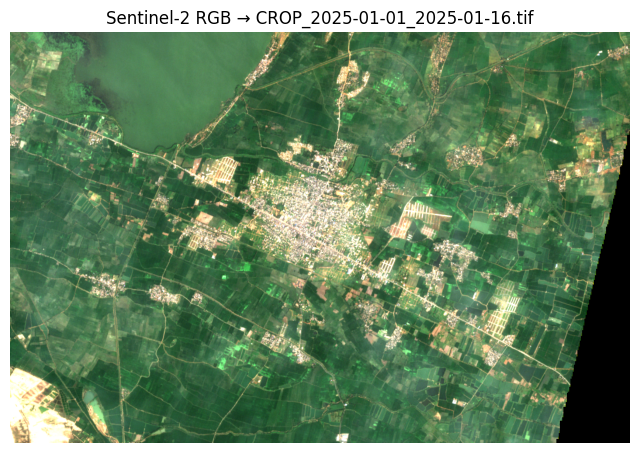

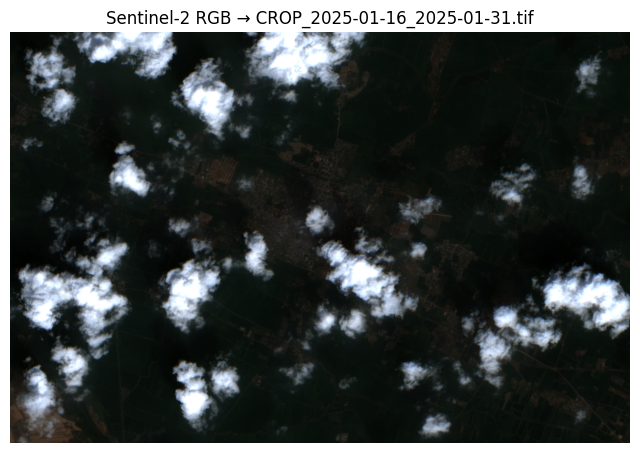

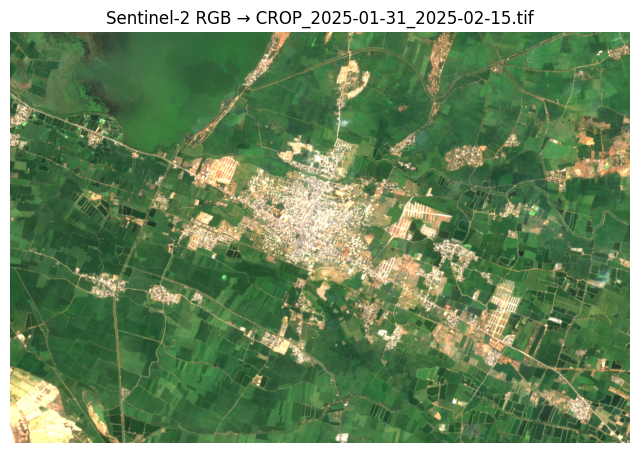

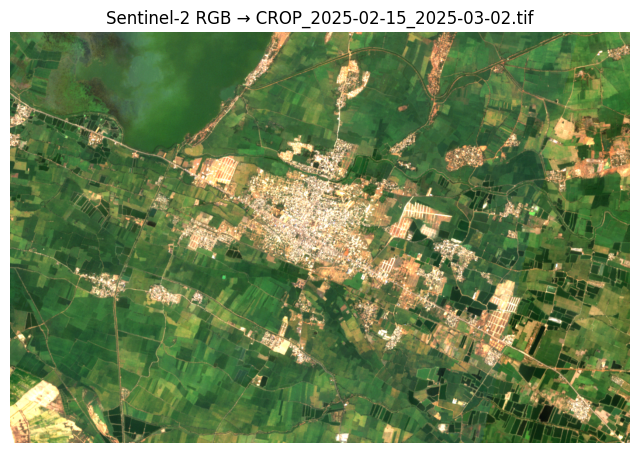

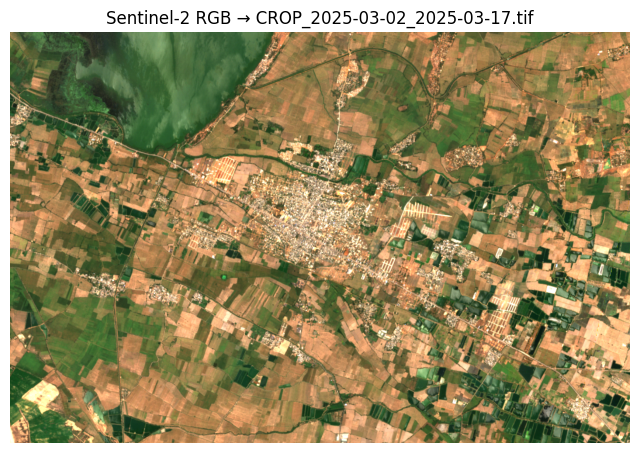

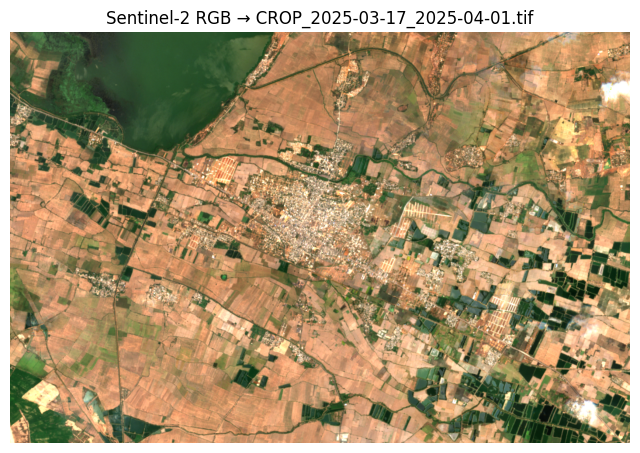

In [7]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Folder containing GeoTIFFs
folder_path = "Sentinel2_7Bands_Median"

# Get all .tif files and sort them
tif_files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(".tif")
])

for tif in tif_files:
    tif_path = os.path.join(folder_path, tif)

    with rasterio.open(tif_path) as src:
        B2 = src.read(1)  # Blue
        B3 = src.read(2)  # Green
        B4 = src.read(3)  # Red

    # Stack as RGB
    rgb = np.dstack((B4, B3, B2))

    # Normalize for display
    rgb = rgb / np.percentile(rgb, 98)

    plt.figure(figsize=(8, 8))
    plt.imshow(np.clip(rgb, 0, 1))
    plt.title(f"Sentinel-2 RGB → {tif}")
    plt.axis("off")
    plt.show()

In [6]:
import ee
import os
import requests
from datetime import datetime

# ==========================================
# INITIALIZE EARTH ENGINE
# ==========================================
ee.Initialize()

# ==========================================
# AOI
# ==========================================
AOI = ee.Geometry.Polygon(
    [[
        [
              79.85118421964597,
              14.56512826180709
            ],
            [
              79.83421275502718,
              14.539062572044742
            ],
            [
              79.91514209483245,
              14.502130756931763
            ],
            [
              79.92944848223556,
              14.527114674597172
            ],
            [
              79.85118421964597,
              14.56512826180709
            ]
    ]]
)
# ==========================================
# OUTPUT FOLDER
# ==========================================
out_dir = "Sentinel2_7Bands_Median"
os.makedirs(out_dir, exist_ok=True)

# ==========================================
# DATE RANGE + WINDOW
# ==========================================
START_DATE = "2025-01-01"
END_DATE   = "2025-04-15"
WINDOW_DAYS = 15         # try 30 if still cloudy
CLOUD_PCT = 20            # scene-level filter

# ==========================================
# HELPERS
# ==========================================
def ee_millis_to_date(millis):
    return datetime.utcfromtimestamp(millis / 1000).strftime("%Y-%m-%d")

def generate_date_windows(start_date, end_date, step_days):
    start = ee.Date(start_date)
    end = ee.Date(end_date)
    offsets = ee.List.sequence(
        0,
        end.difference(start, "day").subtract(step_days),
        step_days
    )
    return offsets.map(
        lambda d: ee.Dictionary({
            "start": start.advance(d, "day").millis(),
            "end": start.advance(d, "day").advance(step_days, "day").millis()
        })
    ).getInfo()

date_windows = generate_date_windows(START_DATE, END_DATE, WINDOW_DAYS)

# ==========================================
# OPTIONAL: SOFT NDVI MASK (gentle cloud cleanup)
# Set USE_SOFT_MASK = False if you want zero masking.
# ==========================================
USE_SOFT_MASK = False
NDVI_THRESH = 0.05

def add_bands_and_indices(img):
    # Raw bands used for ML
    raw = img.select(["B2","B3","B4","B8"])

    # Indices
    ndvi = img.normalizedDifference(["B8","B4"]).rename("NDVI")
    evi = img.expression(
        "2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))",
        {"NIR": img.select("B8"), "RED": img.select("B4"), "BLUE": img.select("B2")}
    ).rename("EVI")
    rendvi = img.normalizedDifference(["B8","B5"]).rename("RENDVI")

    out = raw.addBands([ndvi, evi, rendvi])

    # Soft mask: removes thick clouds/haze-ish pixels without SCL harshness
    if USE_SOFT_MASK:
        out = out.updateMask(ndvi.gt(NDVI_THRESH))
    return out

# ==========================================
# COMPOSITE PER WINDOW (MEDIAN)
# ==========================================
def get_window_composite(start_millis, end_millis):
    start = ee.Date(start_millis)
    end = ee.Date(end_millis)

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(AOI)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", CLOUD_PCT))
        .map(add_bands_and_indices)
    )

    if collection.size().getInfo() == 0:
        print(f"No images for {ee_millis_to_date(start_millis)} → {ee_millis_to_date(end_millis)}")
        return None

    # Median composite over the window
    composite = collection.median().clip(AOI)

    # Ensure band order is stable
    return composite.select(["B2","B3","B4","B8","NDVI","EVI","RENDVI"])

# ==========================================
# DOWNLOAD LOOP
# ==========================================
for w in date_windows:
    start_str = ee_millis_to_date(w["start"])
    end_str   = ee_millis_to_date(w["end"])
    print(f"Processing window: {start_str} → {end_str}")

    comp = get_window_composite(w["start"], w["end"])
    if comp is None:
        continue

    url = comp.getDownloadURL({
        "scale": 10,
        "region": AOI,
        "format": "GeoTIFF"
    })

    filename = f"CROP_{start_str}_{end_str}.tif"
    path = os.path.join(out_dir, filename)
    
    r = requests.get(url)
    with open(path, "wb") as f:
        f.write(r.content)
    print(f"Saved: {path}")

Processing window: 2025-01-01 → 2025-01-16
Saved: Sentinel2_7Bands_Median\CROP_2025-01-01_2025-01-16.tif
Processing window: 2025-01-16 → 2025-01-31
Saved: Sentinel2_7Bands_Median\CROP_2025-01-16_2025-01-31.tif
Processing window: 2025-01-31 → 2025-02-15
Saved: Sentinel2_7Bands_Median\CROP_2025-01-31_2025-02-15.tif
Processing window: 2025-02-15 → 2025-03-02
Saved: Sentinel2_7Bands_Median\CROP_2025-02-15_2025-03-02.tif
Processing window: 2025-03-02 → 2025-03-17
Saved: Sentinel2_7Bands_Median\CROP_2025-03-02_2025-03-17.tif
Processing window: 2025-03-17 → 2025-04-01
Saved: Sentinel2_7Bands_Median\CROP_2025-03-17_2025-04-01.tif


In [8]:
import os
import glob
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
import geopandas as gpd

# ----------------------------
# USER SETTINGS
# ----------------------------
TIFF_DIR = "Sentinel2_7Bands_Median"
POLY_GEOJSON = "Crop_Classification_Images/fields_labeled.geojson"
LABEL_COL = "field_type"
SAMPLES_PER_POLY = 800
SEED = 42

BANDS = ["B2", "B3", "B4", "B8", "NDVI", "EVI", "RENDVI"]
np.random.seed(SEED)

# ----------------------------
# LOAD POLYGONS
# ----------------------------
gdf = gpd.read_file(POLY_GEOJSON)

# keep only labeled polygons
gdf = gdf[gdf[LABEL_COL].notna()].copy()

# normalize labels (important)
gdf[LABEL_COL] = gdf[LABEL_COL].astype(str).str.strip().str.lower()

print("Polygons:", len(gdf), "labels:", sorted(gdf[LABEL_COL].unique()))

# ensure CRS is EPSG:4326
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
elif gdf.crs.to_string() != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

# ----------------------------
# COLLECT TIFF FILES
# ----------------------------
tif_paths = sorted(glob.glob(os.path.join(TIFF_DIR, "*.tif")))
print("TIFFs:", len(tif_paths))

all_dfs = []  # collect per-tif DataFrames (less memory overhead than huge list of dicts)

for tif_path in tif_paths:
    date_tag = os.path.splitext(os.path.basename(tif_path))[0]

    with rasterio.open(tif_path) as src:
        # Sanity check: band count
        if src.count != len(BANDS):
            raise ValueError(
                f"Band mismatch in {tif_path}: raster has {src.count} bands, expected {len(BANDS)} ({BANDS})"
            )

        # Reproject polygons to raster CRS
        gdf_r = gdf.to_crs(src.crs)

        # Optional: read nodata from raster
        raster_nodata = src.nodata

        for poly_idx, feat in gdf_r.iterrows():
            geom = [feat.geometry]
            label = feat[LABEL_COL]

            try:
                # mask returns (bands, H, W)
                arr, _ = mask(src, geom, crop=True, filled=True, nodata=np.nan)
            except ValueError:
                # polygon doesn't overlap raster
                continue

            # convert to float so NaN works reliably
            arr = arr.astype("float32", copy=False)

            # flatten pixels: (bands, H*W) -> (H*W, bands)
            pix = arr.reshape(arr.shape[0], -1).T  # (N, 7)

            # drop invalid pixels
            valid = np.isfinite(pix).all(axis=1)
            pix = pix[valid]

            if pix.shape[0] == 0:
                continue

            # sample a fixed number per polygon per date
            if pix.shape[0] > SAMPLES_PER_POLY:
                sel = np.random.choice(pix.shape[0], SAMPLES_PER_POLY, replace=False)
                pix = pix[sel]

            # vectorized dataframe creation (FAST)
            df_poly = pd.DataFrame(pix, columns=BANDS)
            df_poly.insert(0, "label", label)
            df_poly.insert(1, "date", date_tag)
            df_poly.insert(2, "poly_id", int(poly_idx))  # keep origin polygon id

            all_dfs.append(df_poly)

    # progress
    total_rows = sum(len(d) for d in all_dfs)
    print("Done:", date_tag, "| total rows so far:", total_rows)

# ----------------------------
# SAVE
# ----------------------------
if not all_dfs:
    raise RuntimeError("No pixels extracted. Check polygons overlap with rasters and CRS.")

df = pd.concat(all_dfs, ignore_index=True)
df.to_csv("training_pixels.csv", index=False)

print("Saved: training_pixels.csv | shape:", df.shape)
print(df["label"].value_counts())

Polygons: 20 labels: ['fallow', 'other', 'paddy', 'water']
TIFFs: 6
Done: CROP_2025-01-01_2025-01-16 | total rows so far: 9186
Done: CROP_2025-01-16_2025-01-31 | total rows so far: 18372
Done: CROP_2025-01-31_2025-02-15 | total rows so far: 27558
Done: CROP_2025-02-15_2025-03-02 | total rows so far: 36744
Done: CROP_2025-03-02_2025-03-17 | total rows so far: 45930
Done: CROP_2025-03-17_2025-04-01 | total rows so far: 55116
Saved: training_pixels.csv | shape: (55116, 10)
label
paddy     31026
water      9258
other      8466
fallow     6366
Name: count, dtype: int64


In [9]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# ----------------------------
# USER SETTINGS
# ----------------------------
TRAIN_CSV = "training_pixels.csv"

# Predict on this TIFF (7 bands: B2,B3,B4,B8,NDVI,EVI,RENDVI in this order)
PREDICT_TIF = os.path.join("Sentinel2_7Bands_Median", "CROP_2025-02-15_2025-03-02.tif")
OUT_CLASS_TIF = "classified_map.tif"
OUT_MODEL = "svm_model.joblib"

FEATURES = ["B2","B3","B4","B8","NDVI","EVI","RENDVI"]
LABEL_COL = "label"

# ----------------------------
# 1) Load training data
# ----------------------------
df = pd.read_csv(TRAIN_CSV)

# Basic cleanup
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [LABEL_COL])

X = df[FEATURES].astype(np.float32).values
y = df[LABEL_COL].values

print("Training rows:", len(df))
print("Class counts:\n", pd.Series(y).value_counts())

# ----------------------------
# 2) Train SVM (scaled + balanced)
# ----------------------------
# Pixel-wise split is OK for a quick demo. For best practice, split by poly_id later.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=5.0,
        gamma="scale",
        class_weight="balanced",
        probability=False
    ))
])

print("\nTraining SVM...")
model.fit(X_train, y_train)

print("\nEvaluation on held-out pixels:")
pred = model.predict(X_test)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

joblib.dump(model, OUT_MODEL)
print("✅ Saved model:", OUT_MODEL)

# ----------------------------
# 3) Predict for all pixels in a TIFF
# ----------------------------
print("\nPredicting full image:", PREDICT_TIF)

with rasterio.open(PREDICT_TIF) as src:
    # Read all 7 bands
    # shape: (bands, height, width)
    arr = src.read().astype(np.float32)

    # If nodata exists, handle it; otherwise we'll treat non-finite as invalid later
    nodata = src.nodata

    # Flatten to (N, bands)
    bands, h, w = arr.shape
    if bands != len(FEATURES):
        raise ValueError(f"TIFF has {bands} bands but expected {len(FEATURES)}: {FEATURES}")

    X_img = arr.reshape(bands, -1).T  # (h*w, 7)

    # Valid pixels: finite + (optional nodata check)
    valid = np.isfinite(X_img).all(axis=1)
    if nodata is not None and np.isfinite(nodata):
        valid = valid & np.all(X_img != nodata, axis=1)

    # Prepare output array (uint8 class ids)
    # 0 = nodata/invalid
    out = np.zeros((h*w,), dtype=np.uint8)

    # Map class names to ids (stable ordering)
    classes = sorted(np.unique(y))
    class_to_id = {c: i+1 for i, c in enumerate(classes)}  # start at 1
    id_to_class = {v: k for k, v in class_to_id.items()}
    print("Class mapping:", class_to_id)

    # Predict only valid pixels
    X_valid = X_img[valid]
    y_valid_pred = model.predict(X_valid)

    out_valid_ids = np.array([class_to_id[c] for c in y_valid_pred], dtype=np.uint8)
    out[valid] = out_valid_ids

    out_img = out.reshape(h, w)

    # Save classified map as GeoTIFF
    profile = src.profile.copy()
    profile.update(
        dtype=rasterio.uint8,
        count=1,
        nodata=0,
        compress="lzw"
    )

    with rasterio.open(OUT_CLASS_TIF, "w", **profile) as dst:
        dst.write(out_img, 1)

print("✅ Saved classified GeoTIFF:", OUT_CLASS_TIF)
print("Done.")

Training rows: 55116
Class counts:
 paddy     31026
water      9258
other      8466
fallow     6366
Name: count, dtype: int64

Training SVM...

Evaluation on held-out pixels:
[[1075  113   82    3]
 [ 232 1421   29   11]
 [1258  194 4698   56]
 [  12   19   18 1803]]
              precision    recall  f1-score   support

      fallow       0.42      0.84      0.56      1273
       other       0.81      0.84      0.83      1693
       paddy       0.97      0.76      0.85      6206
       water       0.96      0.97      0.97      1852

    accuracy                           0.82     11024
   macro avg       0.79      0.85      0.80     11024
weighted avg       0.88      0.82      0.83     11024

✅ Saved model: svm_model.joblib

Predicting full image: Sentinel2_7Bands_Median\CROP_2025-02-15_2025-03-02.tif
Class mapping: {'fallow': 1, 'other': 2, 'paddy': 3, 'water': 4}
✅ Saved classified GeoTIFF: classified_map.tif
Done.


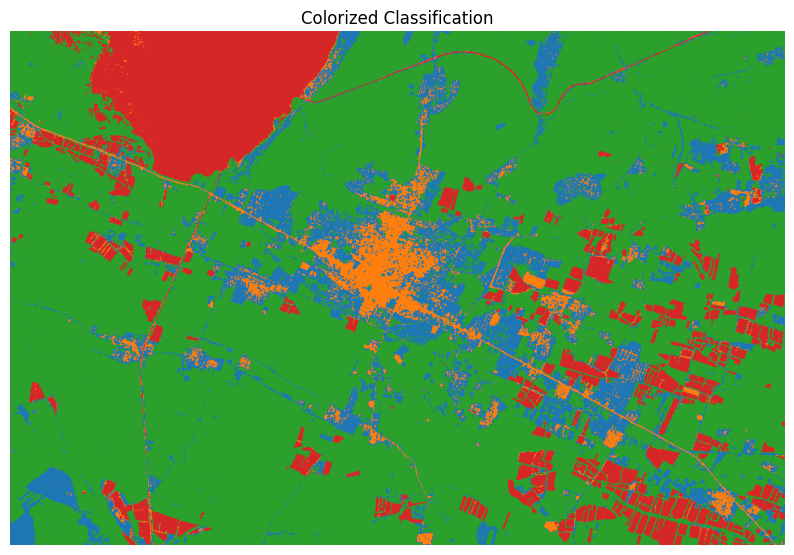

Saved colorized_output.png


In [10]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

tif_path = "classified_map.tif"  # change if needed

with rasterio.open(tif_path) as src:
    arr = src.read(1)

uniq = np.unique(arr).astype(int)
n_classes = int(uniq.max()) + 1

# 0 = black, others = tab10 colors
base = plt.get_cmap("tab10").colors
colors = [(0,0,0)] * n_classes
for k in range(1, n_classes):
    colors[k] = base[(k-1) % len(base)]

cmap = ListedColormap(colors)
bounds = np.arange(-0.5, n_classes + 0.5, 1.0)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10,8))
plt.imshow(arr, cmap=cmap, norm=norm)
plt.title("Colorized Classification")
plt.axis("off")
plt.savefig("colorized_output.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved colorized_output.png")
